In [1]:
import torch

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
a = torch.tensor([1.0, 2.0, 3.0]) #Np array and tensors are same, but tensors get gpu support
b = torch.tensor([4.0, 5.0, 6.0])
print("a:", a)
print("b:", b)


print("a + b:", a + b)
print("a * b:", a * b)

a: tensor([1., 2., 3.])
b: tensor([4., 5., 6.])
a + b: tensor([5., 7., 9.])
a * b: tensor([ 4., 10., 18.])


In [4]:
A = torch.randn(3, 3)
B = torch.randn(3, 3)

print("Matrix A:\n", A)
print("Matrix B:\n", B)
print("A @ B (matrix multiply):\n", A @ B)
print("Transpose of A:\n", A.T)

Matrix A:
 tensor([[ 0.3203, -0.9419, -1.8130],
        [-0.1869,  2.1908,  0.0596],
        [ 0.0810, -0.9960,  0.9459]])
Matrix B:
 tensor([[-0.6000,  0.9901,  0.1481],
        [-0.0435,  0.9923, -0.8862],
        [-1.1354, -1.7072, -0.3722]])
A @ B (matrix multiply):
 tensor([[ 1.9073,  2.4777,  1.5570],
        [-0.0508,  1.8873, -1.9914],
        [-1.0793, -2.5231,  0.5426]])
Transpose of A:
 tensor([[ 0.3203, -0.1869,  0.0810],
        [-0.9419,  2.1908, -0.9960],
        [-1.8130,  0.0596,  0.9459]])


In [5]:
A_gpu = A.to(device)
print("A on device:", A_gpu.device)

A on device: cuda:0


In [6]:
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42) #Synthetic Data Generation
X = torch.randn(100, 1)
y = 3 * X + 2 + torch.randn(100, 1) * 0.1

model = nn.Linear(1, 1)  # import model


criterion = nn.MSELoss() # Utilise Mean square Error loss function
optimizer = optim.SGD(model.parameters(), lr=0.1) # Stochastic Gradient Descent as Optimiser

In [7]:
losses = []

for epoch in range(100):
    optimizer.zero_grad()
    predictions = model(X)
    loss = criterion(predictions, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(f"Learned weight: {model.weight.item():.4f}")  # nearly 3
print(f"Learned bias:   {model.bias.item():.4f}")    # nearly 2

Learned weight: 3.0012
Learned bias:   2.0036


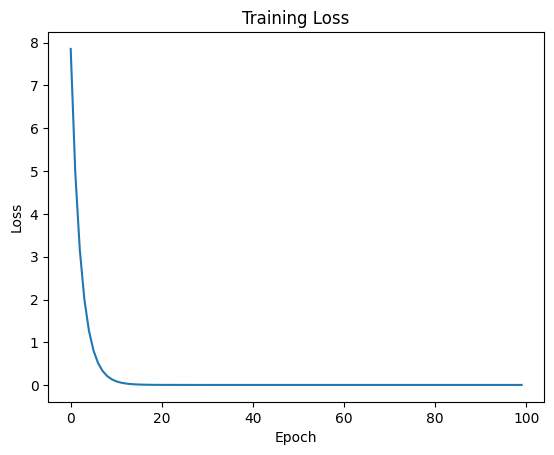

In [8]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()